<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [50]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [95]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [30]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/data_6/data_2d.csv'

data_2d = pd.read_csv(file_path, header=None)
data_2d

,0,1,2
0,0.0,-0.768716,0.460860
1,0.0,2.687848,2.366961
2,0.0,-0.201379,0.470430
3,0.0,0.608496,1.225400
4,0.0,-0.082282,1.137218
...,...,...,...
195,1.0,0.629144,4.378584
196,1.0,-0.723824,5.361801
197,1.0,1.346107,2.333476
198,1.0,3.608219,3.411546


In [31]:
data_2d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       200 non-null    float64
 1   1       200 non-null    float64
 2   2       200 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB


In [32]:
data_2d.describe()

,0,1,2
count,200.000000,200.000000,200.000000
mean,0.500000,1.758886,2.211502
std,0.501255,1.239986,1.605176
min,0.000000,-1.488928,-1.344141
25%,0.000000,0.874456,0.955211
50%,0.500000,1.729753,2.282891
75%,1.000000,2.701499,3.602253
max,1.000000,4.554605,5.722027


In [33]:
data_2d.duplicated().sum()

np.int64(0)

In [58]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_2d)

inertia_2d = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_2d.append(kmeans.inertia_)

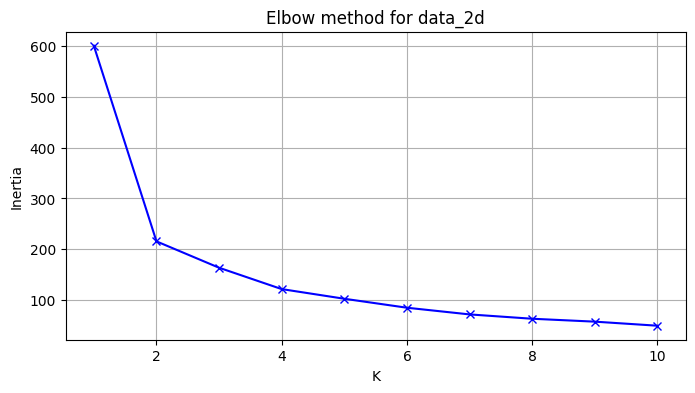

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia_2d, 'bx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow method for data_2d')
plt.grid(True)
plt.show()

In [41]:
optimal_k_2d = 2
kmeans_2d = KMeans(n_clusters=optimal_k_2d, random_state=42, n_init=10)
labels_2d = kmeans_2d.fit_predict(X_scaled)

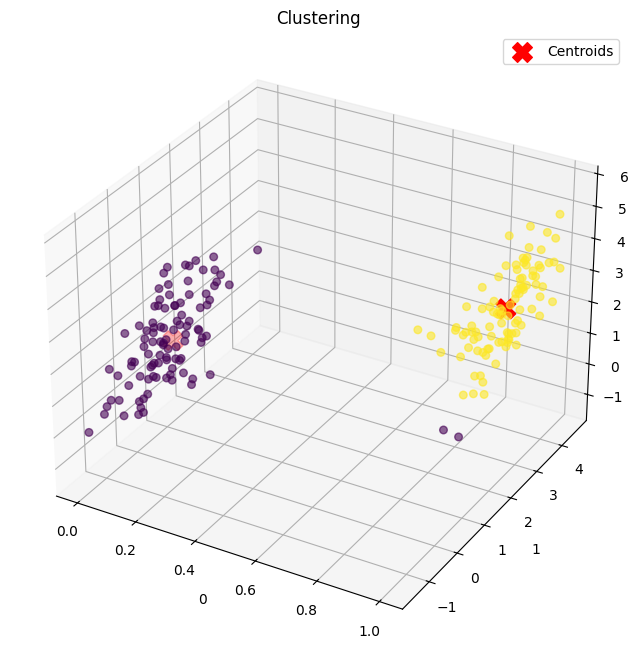

In [49]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data_2d.iloc[:, 0], data_2d.iloc[:, 1], data_2d.iloc[:, 2],
           c=labels_2d, cmap='viridis', s=30, alpha=0.6)

centroids = scaler.inverse_transform(kmeans_2d.cluster_centers_)

ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           s=200, c='red', marker='X', label='Centroids')

ax.set_xlabel('0')
ax.set_ylabel('1')
ax.set_zlabel('2')
ax.set_title('Clustering')
ax.legend()
plt.show()

In [51]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data/data_6/mnist.csv'

mnist = pd.read_csv(file_path, header=None)
mnist

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
mnist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 3.0 MB


In [53]:
mnist.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
780,0
781,0
782,0
783,0


In [54]:
mnist.duplicated().sum()

np.int64(0)

In [60]:
scaler_mnist = StandardScaler()
X_mnist_scaled = scaler_mnist.fit_transform(mnist)

pca = PCA(n_components=2, random_state=42)
X_mnist_pca = pca.fit_transform(X_mnist_scaled)

inertia_mnist = []
K_range = range(1, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_mnist_pca)
    inertia_mnist.append(kmeans.inertia_)

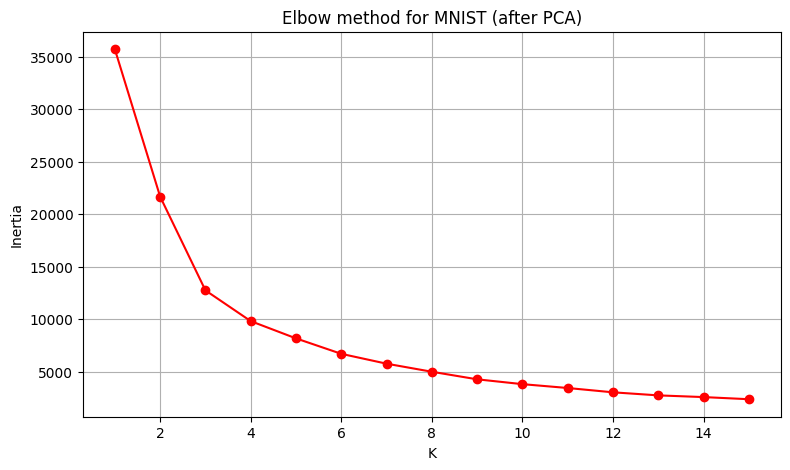

In [61]:
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia_mnist, 'ro-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow method for MNIST (after PCA)')
plt.grid(True)
plt.show()

In [75]:
optimal_k_mnist = 3
kmeans_mnist = KMeans(n_clusters=optimal_k_mnist, random_state=42, n_init=10)
labels_mnist = kmeans_mnist.fit_predict(X_mnist_pca)

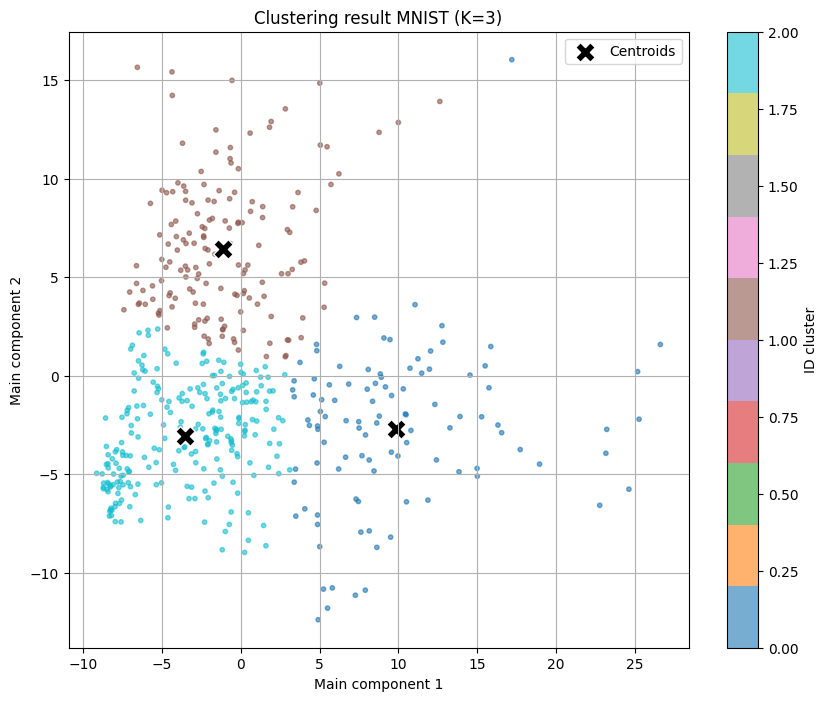

In [76]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(X_mnist_pca[:, 0], X_mnist_pca[:, 1],
                      c=labels_mnist, cmap='tab10', s=10, alpha=0.6)

centroids_mnist = kmeans_mnist.cluster_centers_
plt.scatter(centroids_mnist[:, 0], centroids_mnist[:, 1],
            s=200, c='black', marker='X', edgecolors='white', label='Centroids')

plt.xlabel('Main component 1')
plt.ylabel('Main component 2')
plt.title(f'Clustering result MNIST (K={optimal_k_mnist})')
plt.colorbar(scatter, label='ID cluster')
plt.legend()
plt.grid(True)
plt.show()

In [77]:
X_mnist = mnist.iloc[:, 1:]

scaler_mnist = StandardScaler()
X_mnist_scaled = scaler_mnist.fit_transform(X_mnist)

pca = PCA(n_components=2, random_state=42)
X_mnist_pca = pca.fit_transform(X_mnist_scaled)

In [78]:
inertia_mnist = []
K_range = range(1, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_mnist_pca)
    inertia_mnist.append(kmeans.inertia_)

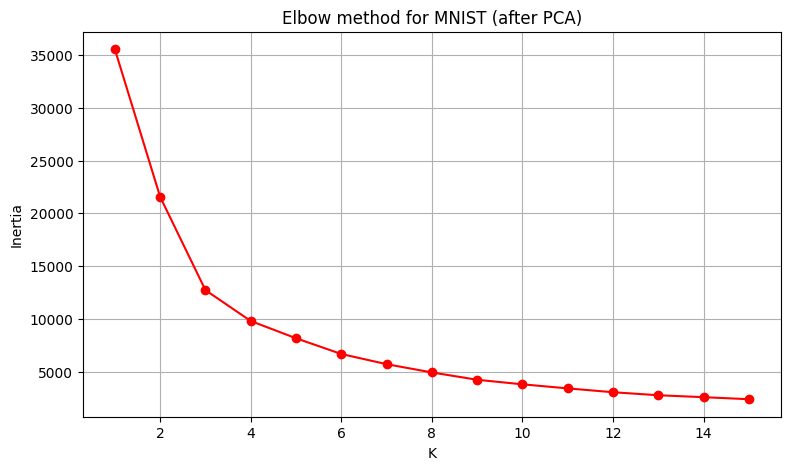

In [79]:
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia_mnist, 'ro-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow method for MNIST (after PCA)')
plt.grid(True)
plt.show()

In [80]:
optimal_k_mnist = 10
kmeans_mnist = KMeans(n_clusters=optimal_k_mnist, random_state=42, n_init=10)
labels_mnist = kmeans_mnist.fit_predict(X_mnist_pca)

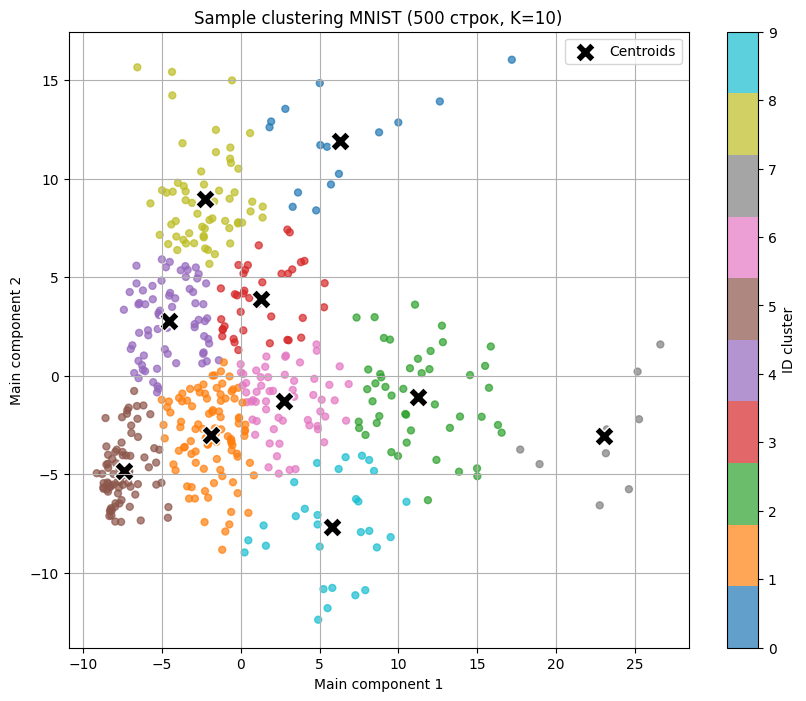

In [81]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_mnist_pca[:, 0], X_mnist_pca[:, 1],
                      c=labels_mnist, cmap='tab10', s=25, alpha=0.7)

centroids_mnist = kmeans_mnist.cluster_centers_
plt.scatter(centroids_mnist[:, 0], centroids_mnist[:, 1],
            s=200, c='black', marker='X', edgecolors='white', label='Centroids')

plt.xlabel('Main component 1')
plt.ylabel('Main component 2')
plt.title(f'Sample clustering MNIST (500 строк, K={optimal_k_mnist})')
plt.colorbar(scatter, label='ID cluster')
plt.legend()
plt.grid(True)
plt.show()

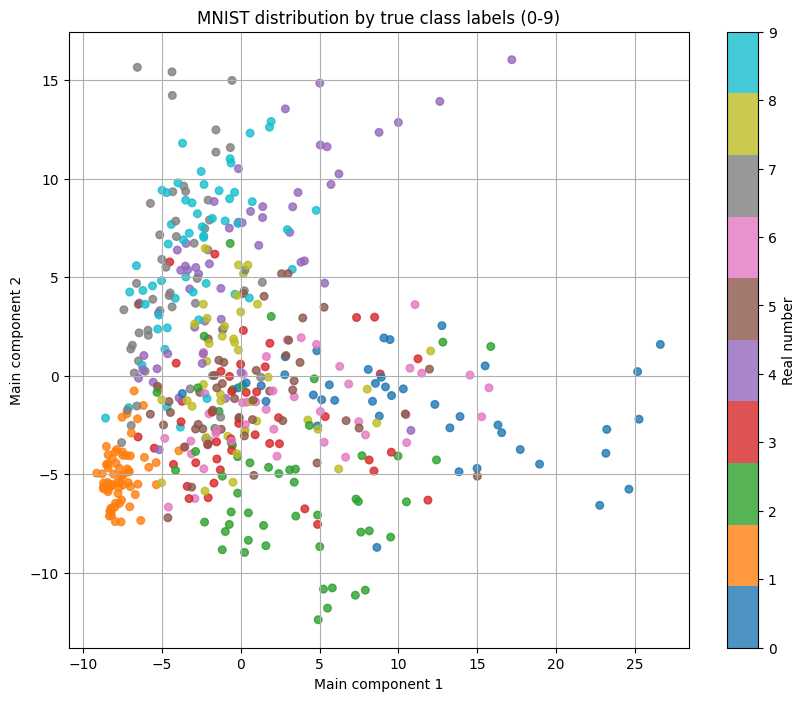

In [82]:
y_mnist = mnist.iloc[:, 0]
X_mnist = mnist.iloc[:, 1:]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mnist)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_mnist, cmap='tab10', s=30, alpha=0.8)

plt.xlabel('Main component 1')
plt.ylabel('Main component 2')
plt.title('MNIST distribution by true class labels (0-9)')

colorbar = plt.colorbar(scatter, ticks=range(10))
colorbar.set_label('Real number')

plt.grid(True)
plt.show()

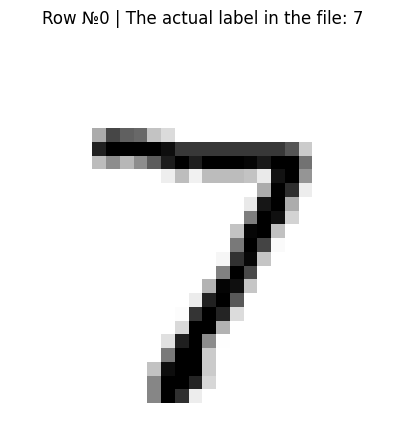

In [94]:
row_index = 0

true_label = mnist.iloc[row_index, 0]
pixels = mnist.iloc[row_index, 1:]

image_matrix = pixels.values.astype('int64').reshape(28, 28)

plt.figure(figsize=(5, 5))
plt.imshow(image_matrix, cmap='gray_r')

plt.title(f'Row №{row_index} | The actual label in the file: {true_label}')
plt.axis('off')
plt.show()

Пояснення для mnist: згідно графіку ліктьового методу видно згин при значенні 3, тому побудовано для цього графік. Але реально це дані з цифрами та яскравістю пікселів. Тому далі вибрано К рівним 10 і побудовано графік для цього значення. Також побудовано графік з реальними мітками та графік зображення цифри.

In [96]:
y_true = mnist.iloc[:, 0]
X_mnist = mnist.iloc[:, 1:]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mnist)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_pca)

ari_score = adjusted_rand_score(y_true, y_pred)
nmi_score = normalized_mutual_info_score(y_true, y_pred)

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

Adjusted Rand Index (ARI): 0.2539
Normalized Mutual Information (NMI): 0.3693


In [97]:
y_true = mnist.iloc[:, 0]
X_mnist = mnist.iloc[:, 1:]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mnist)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

ari_score = adjusted_rand_score(y_true, y_pred)
nmi_score = normalized_mutual_info_score(y_true, y_pred)

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

Adjusted Rand Index (ARI): 0.2659
Normalized Mutual Information (NMI): 0.4276


In [99]:
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_scaled)

kmeans_50 = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_50 = kmeans_50.fit_predict(X_pca_50)

print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(y_true, y_pred_50):.4f}")
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(y_true, y_pred_50):.4f}")

Adjusted Rand Index (ARI): 0.3353
Normalized Mutual Information (NMI): 0.4723
